# EDA — Mi Spotify Wrapped (DWH Analysis)

**Proyecto**: dwh-spotify-wrapped  
**Materia**: Bases de Datos II — Universidad de Pamplona  
**Autor**: Didier  
**Fecha**: 2026-05-18

Análisis exploratorio del Data Warehouse dimensional construido sobre Cloud SQL (PostgreSQL 16).  
Todas las horas pico usan la columna `_cot` (Colombia, UTC-5) para reflejar el comportamiento real del oyente.

---
**Prerequisito**: subir `colab-eda-key.json` (Service Account `sa-colab-eda`) al runtime de Colab.

## 1. Setup — Dependencias y conexión

In [1]:
!pip install "cloud-sql-python-connector[pg8000]" SQLAlchemy pandas matplotlib seaborn numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 4.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()  # subir colab-eda-key.json

import os
key_file = list(uploaded.keys())[0]
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = f"/content/{key_file}"
print(f"Credenciales cargadas: {key_file}")

Saving colab-eda-key.json to colab-eda-key.json
Credenciales cargadas: colab-eda-key.json


In [3]:
from google.cloud.sql.connector import Connector
from google.colab import userdata
import sqlalchemy

INSTANCE_CONNECTION_NAME = "dwh-spotify-wrapped:us-central1:spotify-postgres"
DB_USER     = "postgres"
DB_PASSWORD = userdata.get('DB_PASSWORD')   # ← desde Colab Secrets
DB_NAME     = "postgres"

connector = Connector()

def getconn():
    return connector.connect(
        INSTANCE_CONNECTION_NAME, "pg8000",
        user=DB_USER, password=DB_PASSWORD, db=DB_NAME,
        ip_type="PUBLIC",
    )

engine = sqlalchemy.create_engine("postgresql+pg8000://", creator=getconn)
print("Conexión establecida con Cloud SQL")

Conexión establecida con Cloud SQL


## 2. Carga de datos del DWH

In [4]:
import pandas as pd

df_facts = pd.read_sql("""
    SELECT
        f.id AS history_id,
        f.played_at,
        f.hour_of_day,
        f.day_of_week,
        f.hour_of_day_cot,
        f.day_of_week_cot,
        f.context_type,
        t.name              AS track_name,
        t.lastfm_listeners  AS track_listeners,
        t.lastfm_playcount  AS track_playcount,
        t.duration_ms,
        t.explicit,
        a.name              AS artist_name,
        a.lastfm_listeners  AS artist_listeners,
        a.lastfm_tags       AS artist_tags
    FROM dwh.fact_listening_history f
    JOIN dwh.dim_tracks  t ON f.track_id  = t.track_id
    JOIN dwh.dim_artists a ON t.artist_id = a.artist_id
    ORDER BY f.played_at DESC
""", engine)

df_artists = pd.read_sql("SELECT * FROM dwh.dim_artists", engine)
df_tracks  = pd.read_sql("SELECT * FROM dwh.dim_tracks",  engine)
df_audit   = pd.read_sql("SELECT * FROM dwh.etl_audit ORDER BY started_at", engine)

print(f"Facts         : {len(df_facts):>5} filas")
print(f"Artistas      : {len(df_artists):>5} filas")
print(f"Canciones     : {len(df_tracks):>5} filas")
print(f"Runs ETL      : {len(df_audit):>5} registros")
df_facts.head()

Facts         :   158 filas
Artistas      :    72 filas
Canciones     :   148 filas
Runs ETL      :    17 registros


,history_id,played_at,hour_of_day,day_of_week,hour_of_day_cot,day_of_week_cot,context_type,track_name,track_listeners,track_playcount,duration_ms,explicit,artist_name,artist_listeners,artist_tags
0,124,2026-05-21 02:28:10.305,2,thursday,21,wednesday,playlist,Barrio Antioquia,8278,87288,170531,True,Blessd,271346,"[urbano, Colombia, Latin Trap]"
1,125,2026-05-21 02:25:09.450,2,thursday,21,wednesday,playlist,25/8,165681,1776108,243275,False,Bad Bunny,2609230,"[Reggaeton, trap, latin, puerto rico, trap lat..."
2,126,2026-05-21 02:21:09.367,2,thursday,21,wednesday,playlist,Todo o Nada,35936,407242,159704,True,Eladio Carrion,406926,"[trap, latin, puerto rico, pop, electropop]"
3,127,2026-05-21 02:18:39.541,2,thursday,21,wednesday,playlist,Blessings,5119,31899,184000,True,Omar Courtz,241049,"[Reggaeton, rap, rnb, Hip-Hop, latino]"
4,128,2026-05-21 02:15:39.377,2,thursday,21,wednesday,playlist,PACTO (feat. Bryant Myers & Dei V) - Remix,37648,311495,340000,True,Jay Wheeler,280560,"[latin, puerto rico, Puerto Rican]"


### Observación:
Debido a la fallas técnicas con la API de Spotify decidimos incluir nuevas columnas a el dwh, en cuanto a las columnas que pertenecían a datos nativos de Spotify decidimos dejarlas vacías para futuras mejoras

## 3. ETL Audit — Historial de ejecuciones

In [5]:
audit_display = df_audit[[
    "started_at", "status", "history_new", "history_skipped",
    "artists_new", "tracks_new", "error_message"
]].copy()
audit_display["started_at"] = pd.to_datetime(audit_display["started_at"]).dt.strftime("%Y-%m-%d %H:%M")
print(f"Runs exitosos : {(df_audit.status == 'success').sum()}")
print(f"Total tracks ingresados: {df_audit.history_new.sum()}")
audit_display

Runs exitosos : 16
Total tracks ingresados: 158


,started_at,status,history_new,history_skipped,artists_new,tracks_new,error_message
0,2026-05-15 17:57,success,50,0,50,50,None
1,2026-05-15 18:20,success,0,49,0,0,None
2,2026-05-15 21:10,success,0,48,0,0,None
3,2026-05-18 21:57,success,0,0,0,0,None
4,2026-05-18 22:04,success,50,0,0,0,None
5,2026-05-18 22:16,success,0,0,0,0,None
6,2026-05-19 07:00,success,2,48,0,0,None
7,2026-05-19 18:18,success,6,0,0,0,None
8,2026-05-19 18:20,error,0,0,0,0,(psycopg2.errors.InFailedSqlTransaction) curre...
9,2026-05-19 18:31,success,0,0,0,0,None


# Warning:
el estudiante Didier (Data engineer) realizó la implementación del ETL el día 15 del mes actual con su Spotify asociado a el aplicativo, por ende el eda refleja su comportamiento de escucha

## Estadísticas descriptivas

In [6]:
import numpy as np

#
# Score 0-100 derivado de lastfm_listeners (escala log para que no domine 1 viral)
log_listeners = np.log10(df_artists['lastfm_listeners'].clip(lower=1))
df_artists['popularity_score'] = (
    (log_listeners - log_listeners.min())
    / (log_listeners.max() - log_listeners.min()) * 100
).round(1)

# describe() ahora sí tiene sentido
print(df_artists[['lastfm_listeners', 'popularity_score']].describe())

# Top 10 artistas por popularidad real
print(
    df_artists[['name', 'lastfm_listeners', 'popularity_score']]
    .sort_values('lastfm_listeners', ascending=False)
    .head(10)
    .to_string(index=False)
)

       lastfm_listeners  popularity_score
count      7.200000e+01         72.000000
mean       4.999005e+05         64.501389
std        1.118930e+06         20.766783
min        2.100000e+01          0.000000
25%        2.172225e+04         54.650000
50%        1.457735e+05         69.750000
75%        4.098358e+05         77.875000
max        6.765282e+06        100.000000
          name  lastfm_listeners  popularity_score
         Drake           6765282             100.0
    Bruno Mars           5287793              98.1
   Post Malone           3572833              95.0
     Bad Bunny           2609230              92.5
      J Balvin           1871275              89.9
       KAROL G           1462674              87.9
Rauw Alejandro           1128577              85.9
     Nicky Jam           1084018              85.6
        Maluma           1022109              85.1
         Tainy            819146              83.4


### Observación:
creamos un score nuevo para realizar un análisis de popularidad en base a lastfm_listeners.

In [14]:
df_artists[['popularity', 'followers_count', 'lastfm_listeners']].describe()

,lastfm_listeners
count,72.00
mean,"499,900.50"
std,"1,118,929.77"
min,21.00
25%,"21,722.25"
50%,"145,773.50"
75%,"409,835.75"
max,"6,765,282.00"


In [8]:
# Score 0-100 derivado de lastfm_playcount (escala log para la long-tail)
# Solo aplica a tracks con datos; los NULL quedan como NaN en el score
log_pc = np.log10(df_tracks['lastfm_playcount'].clip(lower=1))
df_tracks['track_popularity_score'] = (
    (log_pc - log_pc.min()) / (log_pc.max() - log_pc.min()) * 100
).round(1)

# Donde no había playcount, el score debe ser NaN (no 0)
df_tracks.loc[df_tracks['lastfm_playcount'].isna(), 'track_popularity_score'] = np.nan

print("Score de popularidad creado.")
print(f"Tracks con score: {df_tracks['track_popularity_score'].notna().sum()} de {len(df_tracks)}")

Score de popularidad creado.
Tracks con score: 148 de 148


### Observación:
La popularidad de los tracks se tranformó en base a un score de lastfm_playcount.

In [9]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("=" * 60)
print("Popularidad de tracks — Last.fm + score derivado")
print("=" * 60)
print(df_tracks[['lastfm_listeners', 'lastfm_playcount', 'track_popularity_score']].describe())

print("\n" + "=" * 60)
print("popularity de Spotify (DEPRECADA — esperado 0 non-null)")
print("=" * 60)
print(df_tracks[['popularity']].notna().sum())

Popularidad de tracks — Last.fm + score derivado
       lastfm_listeners  lastfm_playcount  track_popularity_score
count            148.00            148.00                  148.00
mean          69,951.49        844,487.43                   61.74
std          246,231.23      2,930,257.36                   17.73
min                6.00             12.00                    0.00
25%            4,530.00         26,782.75                   52.80
50%           16,376.50        152,214.50                   64.65
75%           38,644.25        518,346.50                   73.12
max        1,898,587.00     26,454,771.00                  100.00

popularity de Spotify (DEPRECADA — esperado 0 non-null)
popularity    0
dtype: int64


## Preguntas.

### Pregunta 1 — ¿Cuáles son mis 10 artistas más escuchados, Barras horizontales.

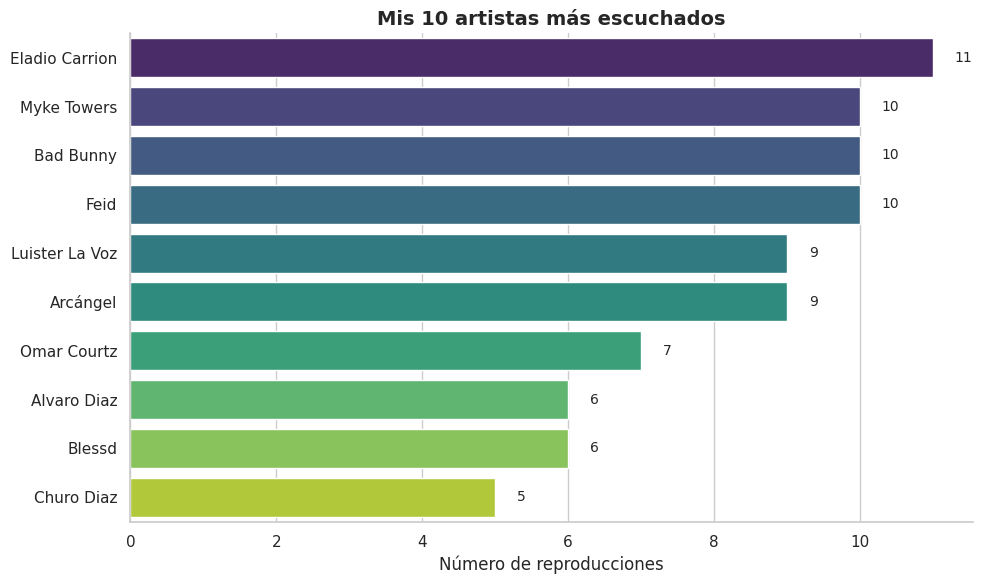

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Top 10 por reproducciones TUYAS
top10 = df_facts['artist_name'].value_counts().head(10).reset_index()
top10.columns = ['artist', 'plays']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, x='plays', y='artist',
            hue='artist', palette='viridis', legend=False, ax=ax)

# Conteo al final de cada barra
for i, v in enumerate(top10['plays']):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)

ax.set_title("Mis 10 artistas más escuchados", fontsize=14, fontweight='bold')
ax.set_xlabel("Número de reproducciones")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

#### Interpretación:
El gráfico de hecho demuestra correctamente el comportamirento de escucha del usuario, no hay nada anómalo en el top con respecto a el segmento de tiempo desde la primera hasta la última ingesta del etl.

### Pregunta 2 — ¿A qué hora del día escucho más música?, gráfico de barras verticales.

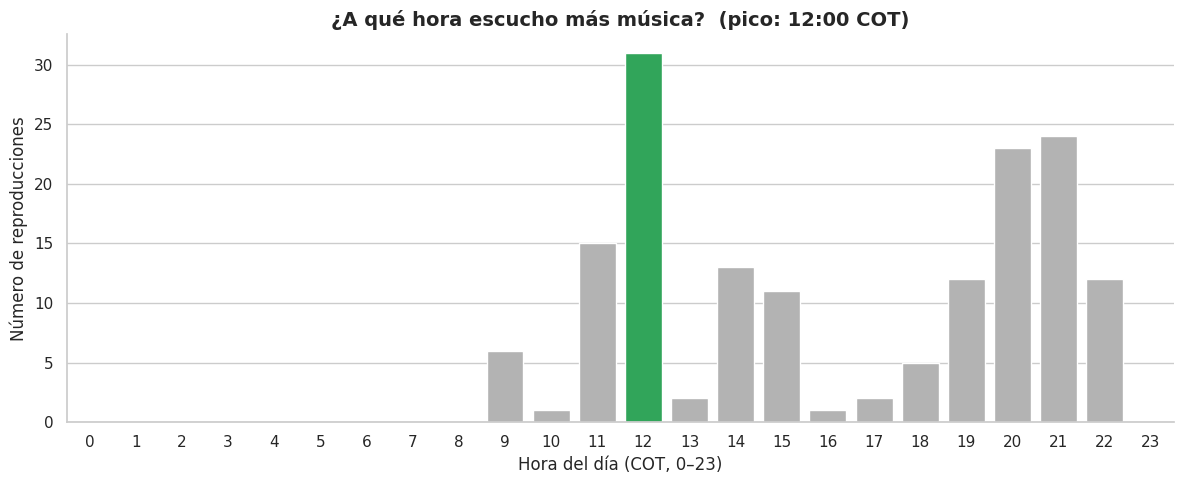

In [16]:
sns.set_theme(style="whitegrid")

horas = (df_facts['hour_of_day_cot']
         .value_counts()
         .reindex(range(24), fill_value=0)
         .reset_index())
horas.columns = ['hora', 'plays']

pico = horas.loc[horas['plays'].idxmax(), 'hora']
colores = ['#1DB954' if h == pico else '#b3b3b3' for h in horas['hora']]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=horas, x='hora', y='plays',
            hue='hora', palette=colores, legend=False, ax=ax)   # ← fix

ax.set_title(f"¿A qué hora escucho más música?  (pico: {pico}:00 COT)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Hora del día (COT, 0–23)")
ax.set_ylabel("Número de reproducciones")
sns.despine()
plt.tight_layout()
plt.show()

#### Interpretación:
Comportamiento esperado, el usuario suele escuchar música mientras camina hacia el restaurante en horas de almuerzo, algo que es casi un hábito.

### Pregunta 3 — ¿Qué tan popular es la música que escucho?, Histograma

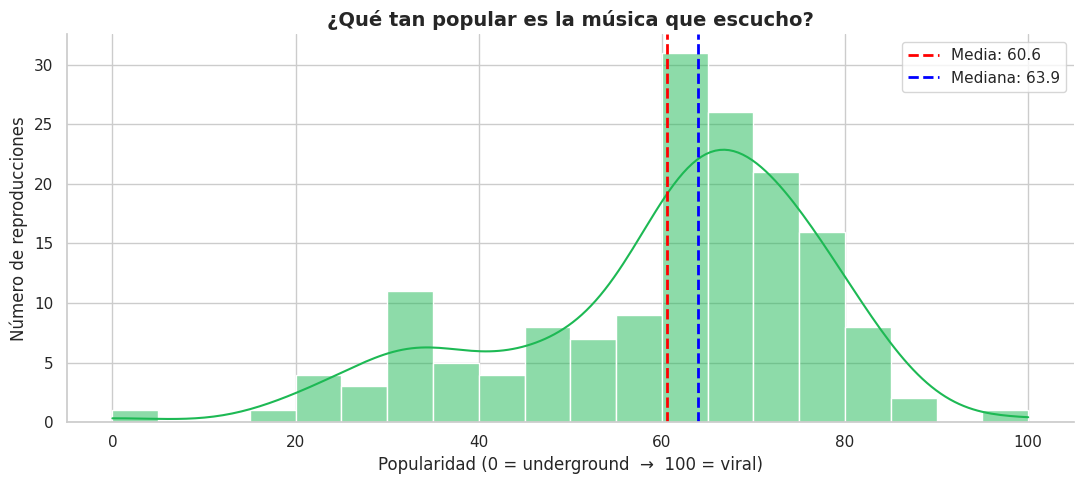

count   158.00
mean     60.59
std      16.84
min       0.00
25%      53.22
50%      63.93
75%      71.67
max     100.00
Name: popularidad, dtype: float64
Moda (bin): 62


In [12]:
sns.set_theme(style="whitegrid")

# Popularidad 0-100 por REPRODUCCIÓN (escala log sobre playcount global Last.fm)
plays = df_facts.dropna(subset=['track_playcount']).copy()
log_pc = np.log10(plays['track_playcount'].clip(lower=1))
plays['popularidad'] = (log_pc - log_pc.min()) / (log_pc.max() - log_pc.min()) * 100

media   = plays['popularidad'].mean()
mediana = plays['popularidad'].median()

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(plays['popularidad'], bins=20, kde=True, color='#1DB954', ax=ax)

ax.axvline(media,   color='red',   ls='--', lw=2, label=f'Media: {media:.1f}')
ax.axvline(mediana, color='blue',  ls='--', lw=2, label=f'Mediana: {mediana:.1f}')

ax.set_title("¿Qué tan popular es la música que escucho?", fontsize=14, fontweight='bold')
ax.set_xlabel("Popularidad (0 = underground  →  100 = viral)")
ax.set_ylabel("Número de reproducciones")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

# Medidas de tendencia central + dispersión
print(plays['popularidad'].describe())
print(f"Moda (bin): {plays['popularidad'].round().mode().iloc[0]:.0f}")

#### Interpretación:
Aunque la mayoría de la música que escucha el usuario está en el promedio (interpretado como música mainstream) hay también una ligera tendencia en un grupo de música no tan popular (más underground).

### Pregunta 4 — ¿Qué géneros dominan mi historial?, barras horizontales

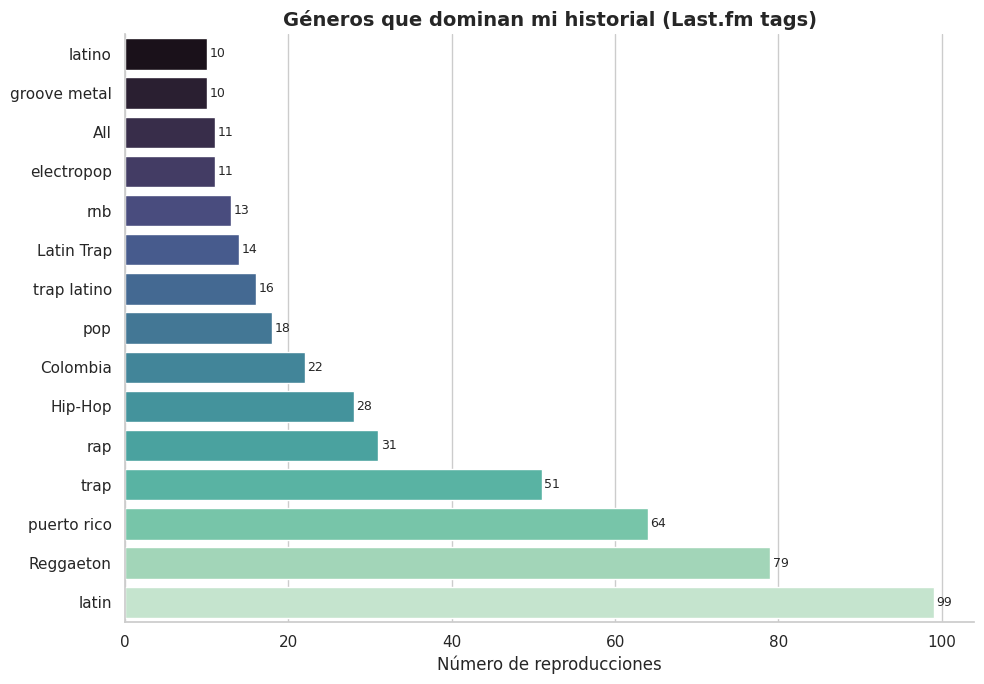

In [13]:


sns.set_theme(style="whitegrid")

# .explode() = UNNEST: una fila por cada tag de cada reproducción
generos = (df_facts['artist_tags']
           .explode()           # abre la lista de tags
           .dropna()            # descarta artistas sin tags
           .value_counts()
           .head(15))

top = generos.sort_values().reset_index()
top.columns = ['genero', 'plays']

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top, x='plays', y='genero',
            hue='genero', palette='mako', legend=False, ax=ax)
for i, v in enumerate(top['plays']):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

ax.set_title("Géneros que dominan mi historial (Last.fm tags)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Número de reproducciones")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

#### Observación:
Aunque no es erroneo afirmar que el usuario escucha en gran medida este género, hay un ligero sesgo en los datos, los artistas pueden estar asociados a varios géneros y en gran medida el que aparece es el latin, la  muestra de artistas que el usuario más escucha también está contaminada con este sesgo, en lo personal hubiera preferido manejar el género desde el track y no desde el artista, de esa forma obtenemos un resultado mucho más determinista en el comportamiento de escucha, manejando de forma unitaria el género, respondiendo esta pregunta con mayor veracidad.

## Conclusiones:

* por el acortamiento del análisis, los resultados obtenidos en los comportamientos en realidad no generaron ninguna novedad, más sin embargo, puede que el análisis extendido pueda sorprendernos futuramente.
* La pregunta de "¿qué géneros dominan mi historial?" resulta ser interesante, pero no de la manera planteada (por artistas) más bien sería interesante llegar a una conclusión por tracks.

###